In [11]:
from z3 import *
import numpy as np
import random
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.autolayout"] = True # to for tight_layout()
import arviz as az
# our library
from z3 import *
import numpy as np
import re
import arviz as az
import matplotlib.pyplot as plt
import os, sys
from importlib import reload
import pickle as pkl
from datetime import datetime

project_root = os.path.abspath(os.path.join(os.getcwd(), "..",))
sys.path.append(project_root)

import src.sat_metropolis.sat as sat
import src.sat_metropolis.smt as smt
import src.sat_metropolis.mcmc as mcmc
import src.sat_metropolis.utils as utils
import src.sat_metropolis.models as models
# from sat_metropolis import smt, mcmc, sat, utils

reload(sat)
reload(smt)
reload(mcmc)
reload(utils)
reload(models)

/Users/efh/Desktop/6. semester/Bachelor/sat-metropolis-businessnisser/src/sat_metropolis/sat.py:303: SyntaxWarning: invalid escape sequence '\*'
  replaced = re.sub('\*', __repl_fun, sampel)


<module 'src.sat_metropolis.models' from '/Users/efh/Desktop/6. semester/Bachelor/sat-metropolis-businessnisser/src/sat_metropolis/models.py'>

In [12]:
# Taken from (Simson Garfinkel, John M. Abowd, Christian Martindale. Understanding Database Reconstruction Attacks on Public Data. Communications of the ACM, March 2019, Vol. 62 No. 3, Pages 46-53. DOI: 10.1145/3287287)

# Assumption, all bit-vectors are of the same size
num_bits = 8
num_vars = 5*2 # (age, gender)
var_list = [BitVec(f'x{i}',num_bits) for i in range(num_vars)] # 0-4 age vars, 5-9 sex vars
x = var_list
g = Goal()
sat.add_bool_vars_to_goal(g, var_list)
g.add(sat.addition_does_not_overflow([x[0], x[1], x[2], x[3], x[4]]))
g.add(sat.addition_does_not_overflow([x[5], x[6], x[7], x[8], x[9]]))
for i in range(5):
    g.add(sat.multi_does_not_overflow([x[i],x[i+5]])) # this is in case of multiplication

# these are binary (obviously only for the purpose of the example)
# FEMALE = 0
# MALE = 1
for i in range(5,10):
    g.add(ULE(0,x[i]))
    g.add(ULE(x[i],1))


# establish an order to set the median
g.add(ULE(0,x[0]))
g.add(ULE(x[0],x[1]))
g.add(ULE(x[1],x[2]))
g.add(ULE(x[2],x[3]))
g.add(ULE(x[3],x[4]))
g.add(ULE(x[4],125))

g.add(x[2] == 30) # median

g.add(x[0] + x[1] + x[2] + x[3] + x[4] == 38*5) # average age

g.add(x[5] + x[6] + x[7] + x[8] + x[9] == 3) # only 3 males

g.add(x[0]*x[5] + x[1]*x[6] + x[2]*x[7] + x[3]*x[8] + x[4]*x[9] == 44*3) # average age of males

# NOTE: we might need to set an overflow constraint for the last sum.


In [17]:
# trace = sat.get_conditional_incremental_samples_sat_pyunigen_problem_cached(
#     z3_problem=g,
#     num_vars=num_vars,
#     num_bits=num_bits,
#     D=3,
#     num_samples=1,
#     num_iterations=1000,
#     sanity_check_problem=True,
#     print_z3_model=False
# )

In [ ]:
import os
import pickle

# ds = [1,3,5,10,20,40]
# samples = [100, 1000, 5000, 10000, 20000]

ds = [1, 5, 10, 20,40,60,80,100]
samples = [100, 1000, 5000, 10000]
backend = "pycmsgen"
runs = 5

results_path = "Results.pkl"

# Use existing Results if already defined; otherwise try loading from pickle
if "Results" in globals():
    print("Using existing Results already in memory.")
elif os.path.exists(results_path):
    with open(results_path, "rb") as f:
        Results = pickle.load(f)
    print(f"Loaded existing results from {results_path}")
else:
    Results = {}
    print("No existing Results in memory or pickle file found. Starting fresh.")

for run in range(runs):
    if run not in Results:
        Results[run] = {}

    for d in ds:
        if d not in Results[run]:
            Results[run][d] = {}

        added_new = False

        for num_samples in samples:
            if num_samples in Results[run][d]:
                print(f"Skipping existing: run={run}, D={d}, samples={num_samples}")
                continue

            print(f"Computing: run={run}, D={d}, samples={num_samples}")

            trace = mcmc.sample_mh_trace_from_z3_model(
                method="incremental",
                backend=backend,
                z3_problem=g,
                D=d,
                num_vars=num_vars,
                num_bits=num_bits,
                parallel_samples=1,
                time_tracking=True,
                num_samples=num_samples,
                print_z3_model=False,
                fast_start=False,
                print_progress=False,
            )

            Results[run][d][num_samples] = trace
            added_new = True

        # Save once after finishing each (run, d) block, but only if something new was added
        if added_new:
            with open(results_path, "wb") as f:
                pickle.dump(Results, f)
            print(f"Saved progress after run={run}, D={d}")

# Final save
with open(results_path, "wb") as f:
    pickle.dump(Results, f)

print(f"All done. Results saved to {results_path}")

Using existing Results already in memory.
Skipping existing: run=0, D=1, samples=100
Skipping existing: run=0, D=1, samples=1000
Skipping existing: run=0, D=1, samples=5000
Skipping existing: run=0, D=5, samples=100
Skipping existing: run=0, D=5, samples=1000
Skipping existing: run=0, D=5, samples=5000
Skipping existing: run=0, D=10, samples=100
Skipping existing: run=0, D=10, samples=1000
Skipping existing: run=0, D=10, samples=5000
Skipping existing: run=0, D=20, samples=100
Skipping existing: run=0, D=20, samples=1000
Skipping existing: run=0, D=20, samples=5000
Skipping existing: run=1, D=1, samples=100
Skipping existing: run=1, D=1, samples=1000
Skipping existing: run=1, D=1, samples=5000
Skipping existing: run=1, D=5, samples=100
Skipping existing: run=1, D=5, samples=1000
Skipping existing: run=1, D=5, samples=5000
Skipping existing: run=1, D=10, samples=100
Skipping existing: run=1, D=10, samples=1000
Skipping existing: run=1, D=10, samples=5000
Skipping existing: run=1, D=20, 

Per-run summary:
    run   D  num_samples  avg_convergence  total_runtime_seconds  \
0     0   1          100         0.128106               0.033629   
1     0   1         1000         0.044289               0.337788   
2     0   1         5000         0.043494               1.737500   
3     0   5          100         0.049523               0.065010   
4     0   5         1000         0.036147               0.711531   
5     0   5         5000         0.061128               3.831050   
6     0  10          100         0.062505               0.120849   
7     0  10         1000         0.045469               1.085693   
8     0  10         5000         0.052104               5.742381   
9     0  20          100         0.077230               0.140272   
10    0  20         1000         0.041874               1.355273   
11    0  20         5000         0.041750               7.156869   
12    1   1          100         0.243693               0.036491   
13    1   1         1000       

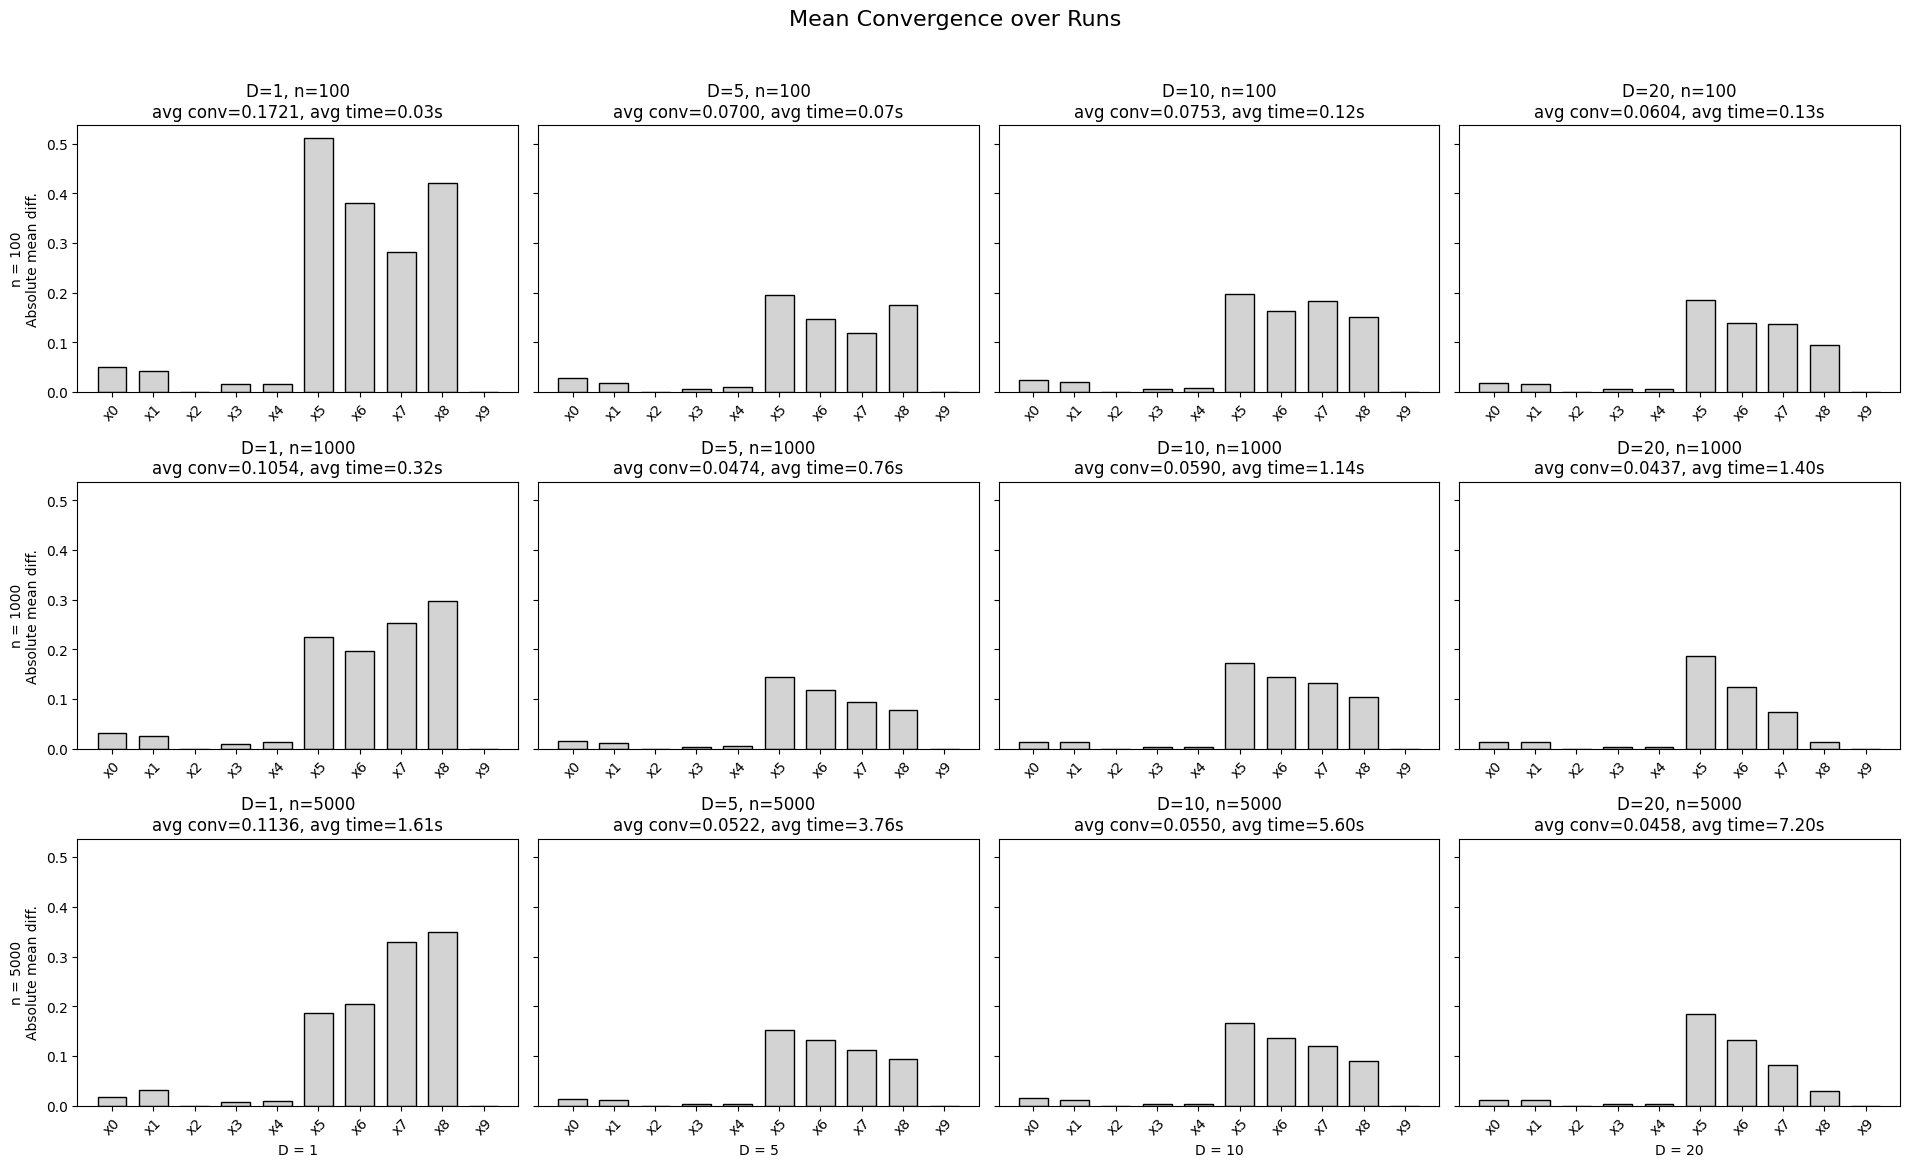


Flat averaged table:
     D  num_samples  avg_convergence  std_convergence  \
0    1          100         0.172115         0.070329   
1    5          100         0.070045         0.027476   
2   10          100         0.075296         0.023873   
3   20          100         0.060377         0.019052   
4    1         1000         0.105366         0.055689   
5    5         1000         0.047447         0.023465   
6   10         1000         0.059050         0.014227   
7   20         1000         0.043698         0.003496   
8    1         5000         0.113634         0.047932   
9    5         5000         0.052204         0.012823   
10  10         5000         0.055049         0.002985   
11  20         5000         0.045847         0.002788   

    avg_total_runtime_seconds  std_total_runtime_seconds  \
0                    0.034587                   0.004504   
1                    0.066448                   0.009247   
2                    0.116111                   0.009419

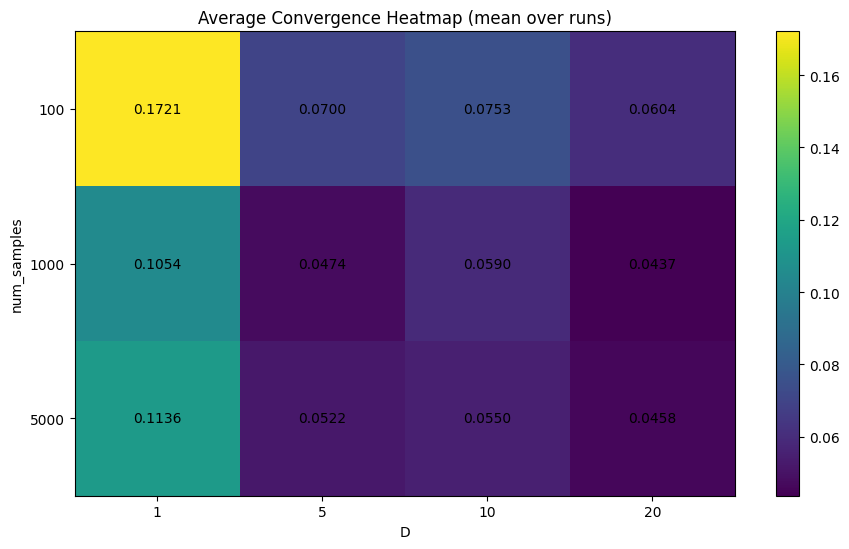

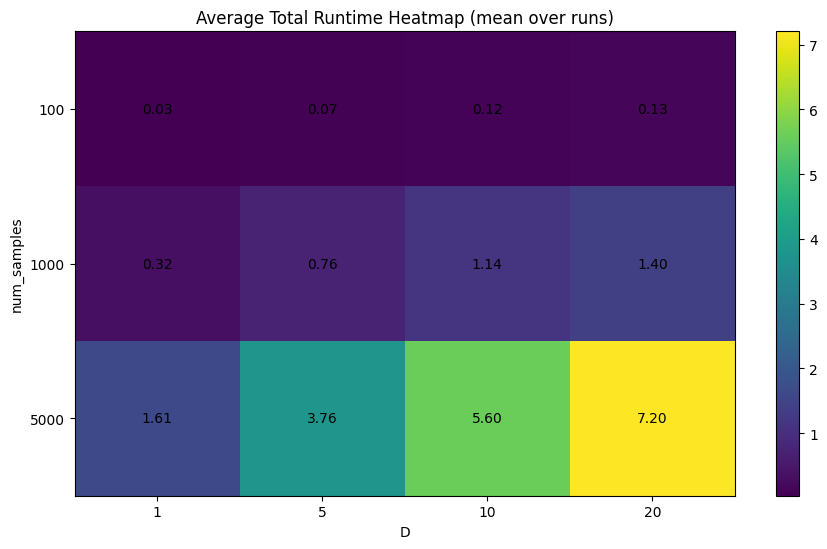


Variable-wise mean errors over runs:
     D  num_samples        x0        x1   x2        x3        x4        x5  \
0    1          100  0.049990  0.041618  0.0  0.016024  0.016920  0.511464   
1    5          100  0.028411  0.018727  0.0  0.007172  0.010761  0.194440   
2   10          100  0.023836  0.021084  0.0  0.006847  0.008131  0.196440   
3   20          100  0.018938  0.016641  0.0  0.006025  0.005935  0.184440   
4    1         1000  0.032383  0.025562  0.0  0.010689  0.013223  0.224488   
5    5         1000  0.015683  0.012529  0.0  0.004293  0.005153  0.145640   
6   10         1000  0.014104  0.013485  0.0  0.003979  0.004266  0.172240   
7   20         1000  0.014775  0.012895  0.0  0.003677  0.004203  0.186040   
8    1         5000  0.018272  0.032519  0.0  0.006626  0.008902  0.186520   
9    5         5000  0.013115  0.012169  0.0  0.003494  0.004356  0.151480   
10  10         5000  0.014941  0.011878  0.0  0.003763  0.004125  0.166960   
11  20         5000  0.012

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ASSUMED RESULTS STRUCTURE
# ============================================================
# Now Results should look like:
#
# Results[run][D][num_samples] = trace
#
# where:
#   run = 1..n  (or any outer keys)
#   trace = [true_trace, times_per_sample]
#
# Example:
# Results = {
#     1: {1: {100: trace, 1000: trace}, 5: {...}},
#     2: {1: {100: trace, 1000: trace}, 5: {...}},
#     ...
# }
# ============================================================


# ============================================================
# 1) ANALYTICAL SOLUTION
# ============================================================

avg_sat = [
    (x0, x1, 30, x3, x4)
    for x0 in range(31)
    for x1 in range(31)
    for x3 in range(30, 126)
    for x4 in range(30, 126)
    if x0 + x1 + 30 + x3 + x4 == 38 * 5
    and x0 <= x1 <= 30 <= x3 <= x4
]

g_sat = [
    (g0, g1, g2, g3, g4)
    for g0 in range(2)
    for g1 in range(2)
    for g2 in range(2)
    for g3 in range(2)
    for g4 in range(2)
    if g0 + g1 + g2 + g3 + g4 == 3
]

sat_models = [
    ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4))
    for (x0, x1, x2, x3, x4) in avg_sat
    for (g0, g1, g2, g3, g4) in g_sat
    if x0 * g0 + x1 * g1 + x2 * g2 + x3 * g3 + x4 * g4 == 44 * 3
]

p_x01 = lambda x: 1 / 31
p_x2  = lambda x: 1
p_x34 = lambda x: 1 / 96
p_g   = lambda x: 1 / 2

unnormalized_probs = np.array([
    p_x01(x0) * p_x01(x1) * p_x2(x2) * p_x34(x3) * p_x34(x4)
    * p_g(g0) * p_g(g1) * p_g(g2) * p_g(g3) * p_g(g4)
    for ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)) in sat_models
])

normalized_probs = unnormalized_probs / unnormalized_probs.sum()

d_exact = {
    'x0': [], 'x1': [], 'x2': [], 'x3': [], 'x4': [],
    'g0': [], 'g1': [], 'g2': [], 'g3': [], 'g4': [],
    'p': []
}

for (((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)), p) in zip(sat_models, normalized_probs):
    d_exact['x0'].append(x0)
    d_exact['x1'].append(x1)
    d_exact['x2'].append(x2)
    d_exact['x3'].append(x3)
    d_exact['x4'].append(x4)
    d_exact['g0'].append(g0)
    d_exact['g1'].append(g1)
    d_exact['g2'].append(g2)
    d_exact['g3'].append(g3)
    d_exact['g4'].append(g4)
    d_exact['p'].append(p)

df_exact = pd.DataFrame(d_exact)

def p_var(var_name, outcome):
    return df_exact.loc[df_exact[var_name] == outcome, 'p'].sum()


# ============================================================
# 2) HELPERS
# ============================================================

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

def get_trace_obj(trace):
    return trace[0]

def get_times_list(trace):
    return trace[1]

def get_outcomes(var_name):
    if var_name in ['x0', 'x1']:
        return range(31)
    elif var_name == 'x2':
        return range(30, 31)
    elif var_name in ['x3', 'x4']:
        return range(30, 126)
    else:
        return range(2)

def analytical_name(sampled_var_name):
    if sampled_var_name in ['x0', 'x1', 'x2', 'x3', 'x4']:
        return sampled_var_name
    return 'g' + str(int(sampled_var_name[1]) - 5)

def p_est_single_chain(trace, var_name, outcome):
    trace_obj = get_trace_obj(trace)
    vals = trace_obj.posterior.sel(chain=0)[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

def variable_convergence_errors(trace):
    errs = {}
    for var in variables:
        outcomes = get_outcomes(var)
        exact_var = analytical_name(var)
        errs[var] = np.mean([
            abs(p_est_single_chain(trace, var, o) - p_var(exact_var, o))
            for o in outcomes
        ])
    return errs

def average_convergence(trace):
    return float(np.mean(list(variable_convergence_errors(trace).values())))

def total_runtime(trace):
    return float(np.sum(get_times_list(trace)))

def avg_time_per_sample(trace):
    return float(np.mean(get_times_list(trace)))


# ============================================================
# 3) SUMMARIZE OVER RUNS
# ============================================================

def build_summary_over_runs(Results, ds, samples):
    """
    Results structure:
        Results[run][d][num_samples] = trace
    """
    run_keys = sorted(Results.keys())

    summary_rows = []
    conv_details_avg = {}      # (d, num_samples) -> mean var-wise error across runs
    conv_details_by_run = {}   # (run, d, num_samples) -> var-wise error dict

    for run in run_keys:
        for d in ds:
            for num_samples in samples:
                trace = Results[run][d][num_samples]

                var_errs = variable_convergence_errors(trace)
                avg_conv = float(np.mean(list(var_errs.values())))
                t_total = total_runtime(trace)
                t_avg = avg_time_per_sample(trace)

                conv_details_by_run[(run, d, num_samples)] = var_errs

                summary_rows.append({
                    'run': run,
                    'D': d,
                    'num_samples': num_samples,
                    'avg_convergence': avg_conv,
                    'total_runtime_seconds': t_total,
                    'avg_time_per_sample_seconds': t_avg
                })

    summary_runs_df = pd.DataFrame(summary_rows)

    # aggregate across runs
    summary_avg_df = (
        summary_runs_df
        .groupby(['D', 'num_samples'], as_index=False)
        .agg(
            avg_convergence=('avg_convergence', 'mean'),
            std_convergence=('avg_convergence', 'std'),
            avg_total_runtime_seconds=('total_runtime_seconds', 'mean'),
            std_total_runtime_seconds=('total_runtime_seconds', 'std'),
            avg_time_per_sample_seconds=('avg_time_per_sample_seconds', 'mean'),
            std_time_per_sample_seconds=('avg_time_per_sample_seconds', 'std'),
            n_runs=('run', 'count')
        )
        .sort_values(['num_samples', 'D'])
        .reset_index(drop=True)
    )

    # average variable-wise errors over runs
    for d in ds:
        for num_samples in samples:
            per_run_errs = []
            for run in run_keys:
                per_run_errs.append(conv_details_by_run[(run, d, num_samples)])

            avg_errs = {
                var: float(np.mean([run_errs[var] for run_errs in per_run_errs]))
                for var in variables
            }
            conv_details_avg[(d, num_samples)] = avg_errs

    return summary_runs_df, summary_avg_df, conv_details_avg, conv_details_by_run


summary_runs_df, summary_avg_df, conv_details_avg, conv_details_by_run = build_summary_over_runs(
    Results, ds, samples
)

print("Per-run summary:")
print(summary_runs_df)

print("\nAveraged over runs:")
print(summary_avg_df)


# ============================================================
# 4) GRID OF BAR CHARTS
#    each subplot uses MEAN VARIABLE-WISE ERROR OVER RUNS
# ============================================================

fig, axes = plt.subplots(
    nrows=len(samples),
    ncols=len(ds),
    figsize=(4.8 * len(ds), 3.8 * len(samples)),
    sharey=True
)

if len(samples) == 1 and len(ds) == 1:
    axes = np.array([[axes]])
elif len(samples) == 1:
    axes = np.array([axes])
elif len(ds) == 1:
    axes = np.array([[ax] for ax in axes])

for i, num_samples in enumerate(samples):
    for j, d in enumerate(ds):
        ax = axes[i, j]
        errs = conv_details_avg[(d, num_samples)]

        row = summary_avg_df[
            (summary_avg_df['D'] == d) &
            (summary_avg_df['num_samples'] == num_samples)
        ].iloc[0]

        ax.bar(
            list(errs.keys()),
            list(errs.values()),
            color='lightgray',
            edgecolor='black',
            width=0.7
        )

        ax.set_title(
            f"D={d}, n={num_samples}\n"
            f"avg conv={row['avg_convergence']:.4f}, "
            f"avg time={row['avg_total_runtime_seconds']:.2f}s"
        )

        ax.tick_params(axis='x', rotation=45)

        if i == len(samples) - 1:
            ax.set_xlabel(f"D = {d}")

        if j == 0:
            ax.set_ylabel(f"n = {num_samples}\nAbsolute mean diff.")

fig.suptitle("Mean Convergence over Runs", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 5) TABLES
# ============================================================

table_basic = summary_avg_df.copy()

print("\nFlat averaged table:")
print(table_basic)

print("\nAverage convergence matrix:")
print(
    table_basic.pivot(
        index='num_samples',
        columns='D',
        values='avg_convergence'
    )
)

print("\nAverage total runtime matrix (seconds):")
print(
    table_basic.pivot(
        index='num_samples',
        columns='D',
        values='avg_total_runtime_seconds'
    )
)

print("\nAverage time per sample matrix (seconds):")
print(
    table_basic.pivot(
        index='num_samples',
        columns='D',
        values='avg_time_per_sample_seconds'
    )
)


# ============================================================
# 6) PRETTY TABLE
# ============================================================

pretty_table = table_basic.copy()

for col in [
    'avg_convergence', 'std_convergence',
    'avg_total_runtime_seconds', 'std_total_runtime_seconds',
    'avg_time_per_sample_seconds', 'std_time_per_sample_seconds'
]:
    pretty_table[col] = pretty_table[col].fillna(0).map(lambda x: f"{x:.6f}")

print("\nPretty averaged summary table:")
print(pretty_table.to_string(index=False))


# ============================================================
# 7) OPTIONAL HEATMAPS
# ============================================================

conv_matrix = table_basic.pivot(index='num_samples', columns='D', values='avg_convergence')
time_matrix = table_basic.pivot(index='num_samples', columns='D', values='avg_total_runtime_seconds')

fig, ax = plt.subplots(figsize=(1.8 * len(ds) + 2, 1.2 * len(samples) + 2))
im = ax.imshow(conv_matrix.values, aspect='auto')

ax.set_xticks(np.arange(len(conv_matrix.columns)))
ax.set_yticks(np.arange(len(conv_matrix.index)))
ax.set_xticklabels(conv_matrix.columns)
ax.set_yticklabels(conv_matrix.index)

ax.set_xlabel("D")
ax.set_ylabel("num_samples")
ax.set_title("Average Convergence Heatmap (mean over runs)")

for i in range(conv_matrix.shape[0]):
    for j in range(conv_matrix.shape[1]):
        ax.text(j, i, f"{conv_matrix.values[i, j]:.4f}", ha='center', va='center')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(1.8 * len(ds) + 2, 1.2 * len(samples) + 2))
im = ax.imshow(time_matrix.values, aspect='auto')

ax.set_xticks(np.arange(len(time_matrix.columns)))
ax.set_yticks(np.arange(len(time_matrix.index)))
ax.set_xticklabels(time_matrix.columns)
ax.set_yticklabels(time_matrix.index)

ax.set_xlabel("D")
ax.set_ylabel("num_samples")
ax.set_title("Average Total Runtime Heatmap (mean over runs)")

for i in range(time_matrix.shape[0]):
    for j in range(time_matrix.shape[1]):
        ax.text(j, i, f"{time_matrix.values[i, j]:.2f}", ha='center', va='center')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


# ============================================================
# 8) OPTIONAL: IF YOU WANT A TABLE OF VARIABLE-WISE MEAN ERRORS
# ============================================================

var_rows = []
for d in ds:
    for num_samples in samples:
        errs = conv_details_avg[(d, num_samples)]
        row = {'D': d, 'num_samples': num_samples}
        row.update(errs)
        var_rows.append(row)

variable_error_table = pd.DataFrame(var_rows).sort_values(['num_samples', 'D']).reset_index(drop=True)

print("\nVariable-wise mean errors over runs:")
print(variable_error_table)

[Inference data with groups:
 	> posterior,
 [0.003950707847252488,
  0.00041512493044137955,
  0.0008243750780820847,
  0.0011600418947637081,
  0.0005548330955207348,
  0.0003926670178771019,
  0.00030387495644390583,
  0.00017891684547066689,
  0.0005780409555882215,
  0.0002817919012159109,
  0.0008273751009255648,
  0.0001710420474410057,
  0.00029341597110033035,
  0.0002210838720202446,
  0.0005407079588621855,
  0.00021016690880060196,
  0.00020575011149048805,
  0.0003332500346004963,
  0.0002881251275539398,
  0.00016724993474781513,
  0.0002366248518228531,
  0.0002946250606328249,
  0.0002944581210613251,
  0.0002367908600717783,
  0.00015537487342953682,
  0.0002126670442521572,
  0.00022737495601177216,
  0.000763084040954709,
  0.000691374996677041,
  0.00030766590498387814,
  0.0003584998194128275,
  0.00022074999287724495,
  0.0002340420614928007,
  0.00019029085524380207,
  0.0003642500378191471,
  0.0002292089629918337,
  0.0002522501163184643,
  0.000517499865964055

In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import math

def plot_distributions(samples):
    keys = list(samples[0].keys())
    n = len(keys)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, key in zip(axes, keys):
        vals = [d[key] for d in samples]
        c = Counter(vals)

        xs = sorted(c.keys())
        total = sum(c.values())
        ys = [c[x] / total for x in xs]

        ax.bar(xs, ys)
        ax.set_title(key)
        ax.set_xlabel("Value")
        ax.set_ylabel("Probability")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) ANALYTICAL SOLUTION
# ============================================================

# list all ages with required median and average age
avg_sat = [
    (x0, x1, 30, x3, x4)
    for x0 in range(31)
    for x1 in range(31)
    for x3 in range(30, 126)
    for x4 in range(30, 126)
    if x0 + x1 + 30 + x3 + x4 == 38 * 5
    and x0 <= x1 <= 30 <= x3 <= x4
]

# list all genders with exactly 3 males
g_sat = [
    (g0, g1, g2, g3, g4)
    for g0 in range(2)
    for g1 in range(2)
    for g2 in range(2)
    for g3 in range(2)
    for g4 in range(2)
    if g0 + g1 + g2 + g3 + g4 == 3
]

# keep only entries with the required average for males
sat_models = [
    ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4))
    for (x0, x1, x2, x3, x4) in avg_sat
    for (g0, g1, g2, g3, g4) in g_sat
    if x0 * g0 + x1 * g1 + x2 * g2 + x3 * g3 + x4 * g4 == 44 * 3
]

# prior on each variable type
p_x01 = lambda x: 1 / 31
p_x2 = lambda x: 1
p_x34 = lambda x: 1 / 96
p_g = lambda x: 1 / 2

# compute unnormalized posterior probabilities
unnormalized_probs = np.array([
    p_x01(x0) * p_x01(x1) * p_x2(x2) * p_x34(x3) * p_x34(x4)
    * p_g(g0) * p_g(g1) * p_g(g2) * p_g(g3) * p_g(g4)
    for ((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)) in sat_models
])

# compute total probability mass (normalizing factor)
total_prob = unnormalized_probs.sum()

# normalized probabilities
normalized_probs = unnormalized_probs / total_prob

# put everything in a dataframe
d = {
    'x0': [], 'x1': [], 'x2': [], 'x3': [], 'x4': [],
    'g0': [], 'g1': [], 'g2': [], 'g3': [], 'g4': [],
    'p': []
}

for (((x0, x1, x2, x3, x4), (g0, g1, g2, g3, g4)), p) in zip(sat_models, normalized_probs):
    d['x0'].append(x0)
    d['x1'].append(x1)
    d['x2'].append(x2)
    d['x3'].append(x3)
    d['x4'].append(x4)
    d['g0'].append(g0)
    d['g1'].append(g1)
    d['g2'].append(g2)
    d['g3'].append(g3)
    d['g4'].append(g4)
    d['p'].append(p)

df = pd.DataFrame(d)

# exact analytical marginal probability
def p_var(var_name, outcome):
    return df.loc[df[var_name] == outcome, 'p'].sum()

# ============================================================
# 2) SINGLE TRACE VS ANALYTICAL SOLUTION
# ============================================================
# Assumes:
#   - `trace` is one ArviZ InferenceData object
#   - trace.posterior contains x0, x1, ..., x9
#
# Mapping:
#   x0..x4  -> exact vars x0..x4
#   x5..x9  -> exact vars g0..g4

def p_est_single(trace, var_name, outcome):
    vals = trace.posterior[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    # support of each variable
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    # map sampled variable name to analytical variable name
    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    # mean absolute difference over the full support
    err = np.mean([
        abs(p_est_single(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)


AttributeError: 'list' object has no attribute 'posterior'

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# empirical probability from ONE CHAIN ONLY (to match your paper code)
def p_est_single_chain(trace, var_name, outcome):
    vals = trace.posterior.sel(chain=0)[var_name].values.reshape(-1)
    return np.mean(vals == outcome)

variables = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

for x in variables:
    if x in ['x0', 'x1']:
        outcomes = range(31)
    elif x == 'x2':
        outcomes = range(30, 31)
    elif x in ['x3', 'x4']:
        outcomes = range(30, 126)
    else:
        outcomes = range(2)

    x_conv = x if x in ['x0', 'x1', 'x2', 'x3', 'x4'] else 'g' + str(int(x[1]) - 5)

    err = np.mean([
        abs(p_est_single_chain(trace, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err)

df_single_trace = pd.DataFrame(data_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

xpos = np.arange(len(df_single_trace))
ax.bar(
    xpos,
    df_single_trace['err_mean_mean'].values,
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace (chain 0 only)'
)

ax.set_xticks(xpos, df_single_trace['var_name'].values, rotation=0)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)

plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'posterior'

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def p_est_original_style(trace_chain0, var_name, outcome):
    return np.mean(trace_chain0[var_name] == outcome).item()

variables = ['x0','x1','x2','x3','x4','x5','x6','x7','x8','x9']

data_single_trace = {
    'var_name': [],
    'err_mean_mean': []
}

trace_chain0 = trace.posterior.sel(chain=0)

for x in variables:
    ran = range(30, 31)
    if x in ['x0', 'x1']:
        ran = range(31)
    elif x in ['x3', 'x4']:
        ran = range(30, 126)
    elif x in ['x5', 'x6', 'x7', 'x8', 'x9']:
        ran = range(2)

    outcomes = ran
    x_conv = x if x in ['x0','x1','x2','x3','x4'] else 'g' + str(int(x[1]) - 5)

    err_outcome_mean = np.mean([
        np.abs(p_est_original_style(trace_chain0, x, o) - p_var(x_conv, o))
        for o in outcomes
    ])

    data_single_trace['var_name'].append(x)
    data_single_trace['err_mean_mean'].append(err_outcome_mean)

df_single_trace = pd.DataFrame(data_single_trace)
print(df_single_trace)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.bar(
    df_single_trace['var_name'],
    df_single_trace['err_mean_mean'],
    color='lightgray',
    edgecolor='black',
    width=0.7,
    label='single trace'
)
ax.set_xlabel('Variables')
ax.set_ylabel(r'Absolute mean diff.   $\mu_{diff}$')
ax.set_title('Single trace vs analytical solution')
ax.legend(loc='upper left')
ax.set_ylim(0, df_single_trace['err_mean_mean'].max() + 0.02)
plt.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'posterior'